calculates entropy for CGA patients 

defined strides 20 overall 

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt


def preprocess_signal_entropy(ts: np.ndarray,
                              fs: float = 100.0,
                              low: float = 0.1,
                              high: float = 3.0) -> np.ndarray:
    """
    1) Detrend (remove any linear drift).
    2) Band-pass filter between low–high Hz (here 0.1–3 Hz).
    3) Z-score the filtered signal.
    4) Plot detrended vs. raw vs. filtered for inspection.
    """
    # 1) Remove linear trend
    ts_d = detrend(ts)

    # 2) Band-pass filter
    nyq = fs / 2
    b, a = butter(4, [low/nyq, high/nyq], btype="bandpass")
    ts_f = filtfilt(b, a, ts_d)

    # 3) Z-score (zero mean, unit variance)
    # ts_z = (ts_f - np.mean(ts_f)) / np.std(ts_f)

    # 4) Plot for visual check
    plt.figure(figsize=(8, 3))
    plt.plot(ts_d, alpha=0.3, label="Detrended (raw)")
    plt.plot(ts,  alpha=0.7, label="Raw")
    plt.plot(ts_f, alpha=1.0, label="Filtered (pre–z-score)")
    plt.title("Preprocessing: Raw vs. Detrended vs. Filtered")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return the z-scored, band-passed signal for entropy
    return ts_f



# ------------------ Entropy Measures ------------------
def approximate_entropy(U: np.ndarray, m: int = 2, r: float = None) -> float:
    """
    Approximate Entropy (ApEn) with m=2, r=0.2*SD default.
    """
    U = np.asarray(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)
    def phi(mv):
        X = np.array([U[i:i+mv] for i in range(N-mv+1)])
        C = [np.mean(np.max(np.abs(X - xi), axis=1) <= r) for xi in X]
        return np.mean(np.log(C))
    return phi(m) - phi(m+1)

def sample_entropy(U: np.ndarray, m: int = 2, r: float = None) -> float:
    """
    Sample Entropy (SampEn) with m=2, r=0.2*SD default.
    """
    U = np.asarray(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)
    X  = np.array([U[i:i+m] for i in range(N-m+1)])
    X1 = np.array([U[i:i+m+1] for i in range(N-m)])
    def count_matches(Xarr):
        cnt = 0
        for i in range(len(Xarr)):
            for j in range(i+1, len(Xarr)):
                if np.max(np.abs(Xarr[i] - Xarr[j])) <= r:
                    cnt += 1
        return cnt
    B = count_matches(X)
    A = count_matches(X1)
    return np.inf if (B == 0 or A == 0) else -np.log(A / B)

# ------------------ Multiscale Entropy ------------------
def coarse_grain(ts: np.ndarray, scale: int) -> np.ndarray:
    """Non-overlapping average for MSE coarse-graining."""
    N = len(ts)
    num = N // scale
    return np.mean(ts[:num*scale].reshape(num, scale), axis=1)

def multiscale_entropy(ts: np.ndarray,
                        m: int = 2,
                        r: float = None,
                        max_scale: int = 20) -> tuple[np.ndarray, np.ndarray]:
    """
    Multiscale Entropy (MSE): SampEn on each coarse-grained series.
    """
    if r is None:
        r = 0.2 * np.std(ts)
    scales = np.arange(1, max_scale + 1)
    mse = np.array([sample_entropy(coarse_grain(ts, s), m, r) for s in scales])
    return scales, mse
    
def compute_entropy_on_acceleration(ts_disp, fs=100.0):
    # 1) Compute velocity and acceleration
    vel = np.gradient(ts_disp, 1/fs)
    acc = np.gradient(vel,    1/fs)

    # 2) Optional band‐pass on acceleration (0.5–10 Hz):
    b, a = butter(4, [0.5/(fs/2), 10/(fs/2)], btype="bandpass")
    acc_f = filtfilt(b, a, acc)

    # 3) Z-score
    acc_z = (acc_f - np.mean(acc_f)) / np.std(acc_f)

    # 4) Entropy
    r = 0.2 * np.std(acc_z)
    ap   = approximate_entropy(acc_z, m=2, r=r)
    samp = sample_entropy    (acc_z, m=2, r=r)

    return ap, samp

def compute_MSE_on_acceleration(ts_disp, fs=100.0):
    # 1) Compute velocity and acceleration
    vel = np.gradient(ts_disp, 1/fs)
    acc = np.gradient(vel,    1/fs)

    # 2) Optional band‐pass on acceleration (0.5–10 Hz):
    b, a = butter(4, [0.5/(fs/2), 10/(fs/2)], btype="bandpass")
    acc_f = filtfilt(b, a, acc)

    # 3) Z-score
    acc_z = (acc_f - np.mean(acc_f)) / np.std(acc_f)

    # 4) Entropy
    r = 0.2 * np.std(acc_z)

    scales, mse = multiscale_entropy(acc_z, m=2, r=r, max_scale=20)

    return  scales, mse





# Patient 4

## PWS

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Dataset loaded. Variables: ['markers']
Using the first 50 left‐leg FOOT‐OFF events:
  Start time (1st L_FO) = 10.5200 s
  End   time (50th L_FO) = 66.1700 s
--- x-axis ---


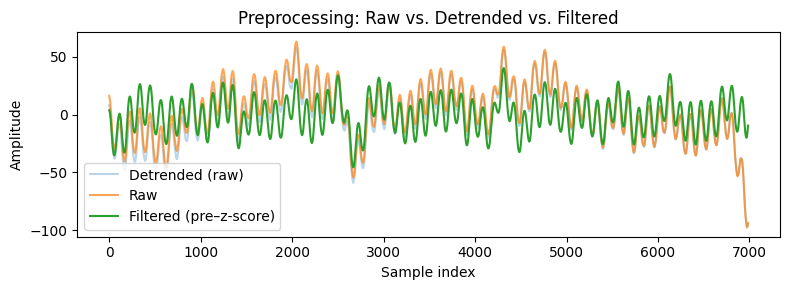

[  3.73065001   3.47229434   3.21511546 ... -11.38788076 -10.46625147
  -9.54404543]
Start index: 1052, End index: 6617
Signal length: 5565 samples
ApEn   (m=2, r=0.2σ) = 0.1610
SampEn (m=2, r=0.2σ) = 0.1654
Multiscale Entropy (m=2, r=0.2σ) = [0.16540453 0.38323472 0.47102536 0.50134688 0.52911189 0.55118025
 0.57286333 0.59441663 0.62337084 0.67788677 0.69494413 0.73151455
 0.75246376 0.83017314 0.81560468]


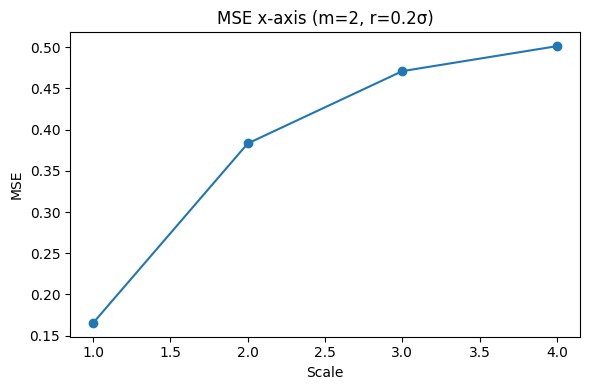


--- y-axis ---


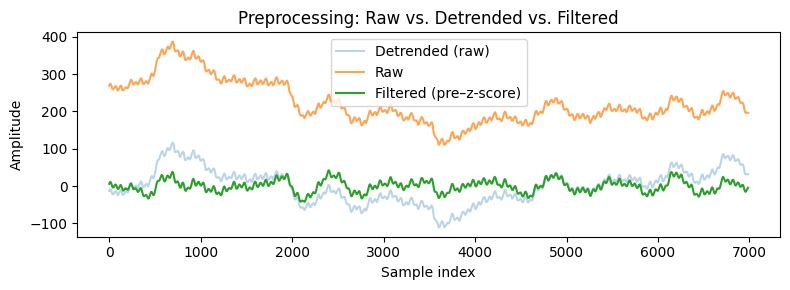

[ 6.02142286  6.68137117  7.33493654 ... -5.47769622 -5.07541371
 -4.67851381]
Start index: 1052, End index: 6617
Signal length: 5565 samples
ApEn   (m=2, r=0.2σ) = 0.1133
SampEn (m=2, r=0.2σ) = 0.1109
Multiscale Entropy (m=2, r=0.2σ) = [0.11086622 0.26105858 0.40338905 0.5000881  0.56304896 0.62644603
 0.69783443 0.79732262 0.90367456 1.00072982 1.11419581 1.16616112
 1.26684008 1.30324687 1.35057628]


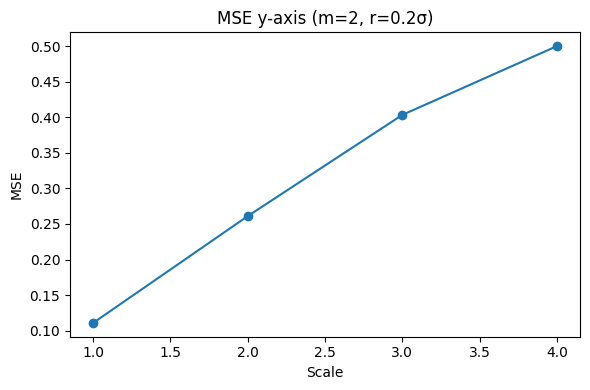


--- z-axis ---


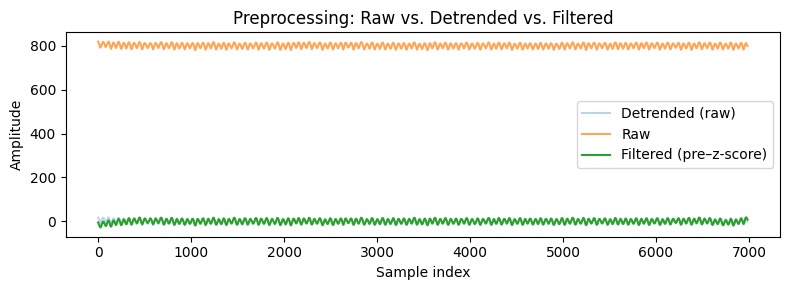

[-5.04213152 -5.96044019 -6.89313703 ...  9.80777981  8.90337025
  8.01852437]
Start index: 1052, End index: 6617
Signal length: 5565 samples
ApEn   (m=2, r=0.2σ) = 0.3387
SampEn (m=2, r=0.2σ) = 0.3376
Multiscale Entropy (m=2, r=0.2σ) = [0.33763649 0.36422131 0.40353157 0.43438687 0.43726839 0.42427744
 0.4482733  0.44219139 0.47476859 0.4814142  0.50878272 0.51255359
 0.61107671 0.61202164 0.66804126]


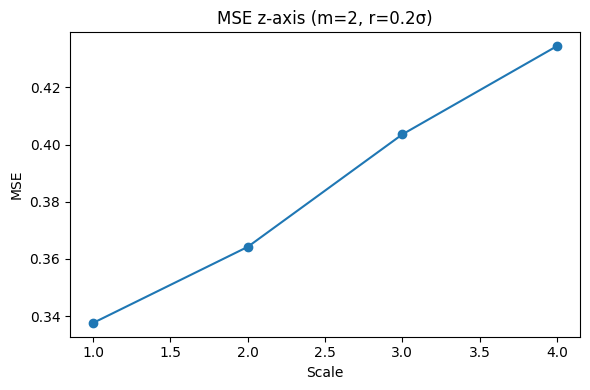

In [4]:
import pandas as pd
cwd = Path.cwd()
print("Current working directory:", cwd.resolve())
data_path = cwd.parent / ".." /"data"/"CGA" /"04"/"PWS"/"4"/"markers.nc"
events_path  = cwd.parent / ".." /"data"/"CGA" /"04"/"PWS"/"4"/"PWS.4_events.csv"

# print("Data file:", data_path.resolve(), "Exists?", data_path.exists())

ds = xr.open_dataset(data_path)
print("Dataset loaded. Variables:", list(ds.data_vars.keys()))
  # ← path to your events.csv
fs = 100.0                      # sampling frequency in Hz

# How many consecutive left‐leg strides you want:
N_STRIDES = 50
SKIP_SAMPLES = 1000
skip_time = SKIP_SAMPLES / fs
df = pd.read_csv(events_path)

# Make sure we have the expected columns
required_cols = {'time', 'label', 'context', 'icon_id'}
if not required_cols.issubset(df.columns):
    raise ValueError(
        f"Expected columns {required_cols} in events.csv, but got {df.columns.tolist()}"
    )

left_fo_df = df[
    (df["context"] == "Left")
    & (df["label"]   == "Foot Off")
    & (df["time"]    >= skip_time)
].copy()

left_fo_df.sort_values(by="time", inplace=True)

if len(left_fo_df) < N_STRIDES:
    raise ValueError(
        f"Found only {len(left_fo_df)} left‐leg foot‐off events, but need {N_STRIDES}."
    )

first_n = left_fo_df.iloc[:N_STRIDES]

start_time = first_n["time"].iloc[0]
end_time   = first_n["time"].iloc[-1]

print(f"Using the first {N_STRIDES} left‐leg FOOT‐OFF events:")
print(f"  Start time (1st L_FO) = {start_time:.4f} s")
print(f"  End   time ({N_STRIDES}th L_FO) = {end_time:.4f} s")

com = ds["markers"].sel(channel="COM")

fs = 100.0


for axis in ("x", "y", "z"):
    print(f"--- {axis}-axis ---")
    ts_raw = com.sel(axis=axis).values.ravel()
    ts = preprocess_signal_entropy(ts_raw, fs)
    print(ts[::])
    start = int(start_time * fs)
    end = int(end_time * fs)
    print(f"Start index: {start}, End index: {end}")
    ts = ts[start:end]
    print(f"Signal length: {len(ts)} samples")
    
    
    r = 0.2 * np.std(ts)

    
    
    # ap_ac, samp_ac = compute_entropy_on_acceleration(ts, fs)
    # mse_ac = compute_MSE_on_acceleration(ts, fs)
    # print(f"ApEn   (m=2, r=0.2σ) = {ap_ac:.4f}")
    # print(f"SampEn (m=2, r=0.2σ) = {samp_ac:.4f}")
    # print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse_ac}")

    

    ap = approximate_entropy(ts, m=2, r=r)
    print(f"ApEn   (m=2, r=0.2σ) = {ap:.4f}")
    samp = sample_entropy(ts, m=2, r=r)
    print(f"SampEn (m=2, r=0.2σ) = {samp:.4f}")
    scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=15)
    print(f"Multiscale Entropy (m=2, r=0.2σ) = {mse}")
    

    # Multiscale Entropy (MSE)
    scales, mse = multiscale_entropy(ts, m=2, r=r, max_scale=4)
    plt.figure(figsize=(6,4))
    plt.plot(scales, mse, 'o-')
    plt.title(f"MSE {axis}-axis (m=2, r=0.2σ)")
    plt.xlabel("Scale")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()
    print()

